In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
def check_memory():
    import sys
    ipython_vars = ["In", "Out", "exit", "quit", "get_ipython", "ipython_vars"]
    print("Top 10 objects with highest memory usage")
    # Get a sorted list of the objects and their sizes
    mem = {
        key: round(value/1e6,2)
        for key, value in sorted(
            [
                (x, sys.getsizeof(globals().get(x)))
                for x in globals()
                if not x.startswith("_") and x not in sys.modules and x not in ipython_vars
            ],
            key=lambda x: x[1],
            reverse=True)[:10]
    }
    print({key:f"{value} MB" for key,value in mem.items()})
    print(f"\n{round(sum(mem.values()),2)/1000} GB in use overall")

In [4]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    W = f['W'][:]
    QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [103]:
################################################################################

In [5]:
# binary_array_path=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5' #DONT USE WITH LOOP INDEXING
# with h5py.File(binary_array_path, 'r') as f:
#     # Load the dataset by its name
#     X = f['X'][:]

# Reading Back Data Later
##################################################################
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
binary_array_path=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'
def read_ZYX(t,p):
    with h5py.File(binary_array_path, 'r') as f:
        # Load the dataset by its name
        Z_tp = f['Z'][t,p]
        Y_tp = f['Y'][t,p]
        X_tp = f['X'][t,p]
    return Z_tp,Y_tp,X_tp

#DOMAIN SUBSETTING
def DOMAIN_SUBSET(out_arr):
    print(f'length before: {len(out_arr)}')

    ocean_percent=2/8
    left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
    
    where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
    where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
    end_xh=len(data['xh'])-1-50
    end_xf=len(data['xf'])-1-50
    
    print(f'x in {0}:{where_coast_xh-1} FOR SEA')
    print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
    # t_end=78 
    # if res=='250m':t_end=410
    # print(f't in {0}:{t_end} (6.5 hours)')
    t_start=36 
    t_end=len(data['time'])
    print(f't in {t_start}:end (8 hours)')

    #SUBSETTING CODE
    row,col=list(out_arr[:,1]),list(out_arr[:,0])
    
    # xs=X[row,col] #FANCY INDEXING
    
    #LOOP INDEXING (slightly longer, but avoids loading X into memory)
    ################
    with h5py.File(binary_array_path, 'r') as f:
        xs=[]
        for i, j in zip(row, col):
            xs.append(f['X'][i, j])
        xs=np.array(xs)
    ################
    
    out_arr=out_arr[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
    out_arr=out_arr[np.where(out_arr[:,1]<=t_end)]

    print(f'length after: {len(out_arr)}')
    return out_arr

In [6]:
# out=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
# save=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')

############################################################
#SUBSETTING
subset=True
if subset==True:
    out_arr=DOMAIN_SUBSET(out_arr)
    save_arr=DOMAIN_SUBSET(save_arr)
############################################################

ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
list of first 10 ignored parcels
[[72 65 72]
 [149 52 57]
 [160 54 59]
 [232 53 58]
 [246 55 59]]
there are a total of 14941 CL parcels and 14725 nonCL parcels
length before: 14941
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 14894
length before: 14725
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 11170


In [7]:
#SHALLOW
parcel_z=parcel['z'].data

def ddt(f,dt=1):
    ddx = (
            f[1:  ]
            -
            f[0:-1]
        ) / (
        2 * dt
    )
    return ddx

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

0/14894
5000/14894
10000/14894
0/11170
5000/11170
10000/11170
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 10240 CL parcels and 8498 nonCL parcels


In [8]:
#DEEP
parcel_z=parcel['z'].data

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

0/14894
5000/14894
10000/14894
0/11170
5000/11170
10000/11170
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 1513 CL parcels and 1130 nonCL parcels


In [9]:
#FIND WHERE PARCEL LEAVES UPDRAFT (FOR ALL AND DEEP PARCELS)
def find_after_time(out_arr):
    wthresh=0.5;qcqithresh=1e-6
    
    after_array=np.zeros(len(out_arr),dtype=int)
    for count,out_row in enumerate(out_arr): 
        
        p=out_row[0]
        t2=out_row[2]
        
        wthresh=0.5;qcqithresh=1e-6
        after=np.where((W[t2:,p]<wthresh)|(QCQI[t2:,p]<qcqithresh))
        if len(after[0])!=0:
            after_array[count]=after[0][0]
    return after_array

ALL_out_after_array=find_after_time(ALL_out_arr)
SHALLOW_out_after_array=np.zeros(len(SHALLOW_out_arr),dtype=int)
DEEP_out_after_array=find_after_time(DEEP_out_arr)

ALL_save_after_array=find_after_time(ALL_save_arr)
SHALLOW_save_after_array=np.zeros(len(SHALLOW_save_arr),dtype=int)
DEEP_save_after_array=find_after_time(DEEP_save_arr)

# # Create a figure and specify gridspec layout
# fig = plt.figure(figsize=(8, 4))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])  # 1 row, 2 columns
# ax0 = plt.subplot(gs[0])
# ax0.hist(ALL_after_array, bins=25)
# ax0.set_xlabel('time')
# ax0.set_ylabel('count')
# ax0.set_title('ALL_after')
# ax1 = plt.subplot(gs[1])
# ax1.hist(DEEP_after_array, bins=25)
# ax1.set_xlabel('time')
# ax1.set_ylabel('count')
# ax1.set_title('DEEP_after')
# plt.tight_layout()

# # Multiply x-ticks by 5
# xticks = ax0.get_xticks()  # Get current x-tick positions
# ax0.set_xticks(xticks)  # Set the same ticks
# ax0.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# # Multiply x-ticks by 5
# xticks = ax1.get_xticks()  # Get current x-tick positions
# ax1.set_xticks(xticks)  # Set the same ticks
# ax1.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# ax0.set_xlim(left=0);ax1.set_xlim(left=0)

In [109]:
#ALL/DEEP/SHALLOW CL vs non-CL Tracked Parcel Plots
################################################################################

In [110]:
#FINDING MEAN CLOUD BASE 
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'


if type=='all':
    out_arr=ALL_out_arr.copy()
elif type=='deep':
    out_arr=DEEP_out_arr.copy()
elif type=='shallow':
    out_arr=SHALLOW_out_arr.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_arr.shape[0]):
    if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
    p=out_arr[row,0]
    
    # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
    ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_arr[row, 1], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]

    ws=W[ts,p]
    qcqis=QCQI[ts,p]
    where=np.where((ws>=w_thresh2) & (qcqis>=qcqi_thresh))
    profile_array[zs[where],0]+=1
del after
# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

0/14894
3000/14894
6000/14894
9000/14894
12000/14894
1.2463868


In [111]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

Text(0.5, 1.0, 'Trajectory Plot')

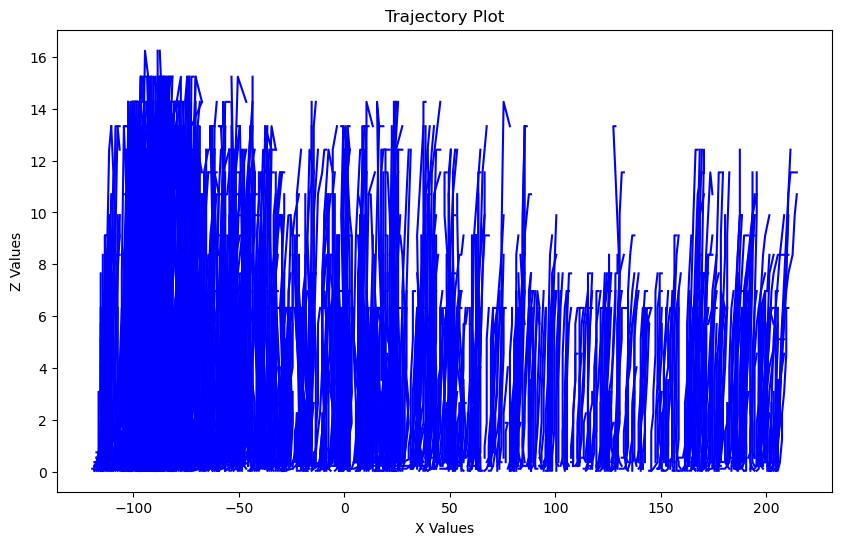

In [112]:
import matplotlib.pyplot as plt
import numpy as np

def CLTrajectoryPlot(ax, type):
    """
    Plot the trajectory based on the type with color corresponding to the type.
    
    Parameters:
    - ax: Matplotlib axes object to plot on.
    - type: Type of plot ('all', 'shallow', 'deep')
    """
    zhs = data['zh'].values
    xhs = data['xh'].values
    
    # Select the correct arrays based on type
    if type == 'all':
        out_arr = ALL_out_arr.copy()
        after_array = ALL_out_after_array
    elif type == 'shallow':
        out_arr = SHALLOW_out_arr.copy()
        after_array = SHALLOW_out_after_array
    elif type == 'deep':
        out_arr = DEEP_out_arr.copy()
        after_array = DEEP_out_after_array
    
    # Loop through each row of out_arr to plot
    for row in range(out_arr.shape[0]):
        after = after_array[row]
        p = out_arr[row, 0]
        
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time']))  # Ensure not exceeding the buffer
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs = Z[ts, p]  # Assuming Z and X are defined and hold the data
        xs = X[ts, p]
        
        z_values = zhs[zs]
        x_values = xhs[xs]

        # Determine the color based on the 'type'
        if type == 'all':
            color = 'black'
        elif type == 'shallow':
            color = 'green'
        elif type == 'deep':
            color = 'blue'
        
        # Plot using ax.plot()
        ax.plot(x_values, z_values, color=color)

# Create a figure and axes outside the function
fig, ax = plt.subplots(figsize=(10, 6))  # You can adjust the size as needed

# Call the function with the 'deep' type and pass in the axes object (ax)
CLTrajectoryPlot(ax=ax, type='deep')

# Optionally, add labels and title
ax.set_xlabel('X Values')
ax.set_ylabel('Z Values')
ax.set_title('Trajectory Plot')

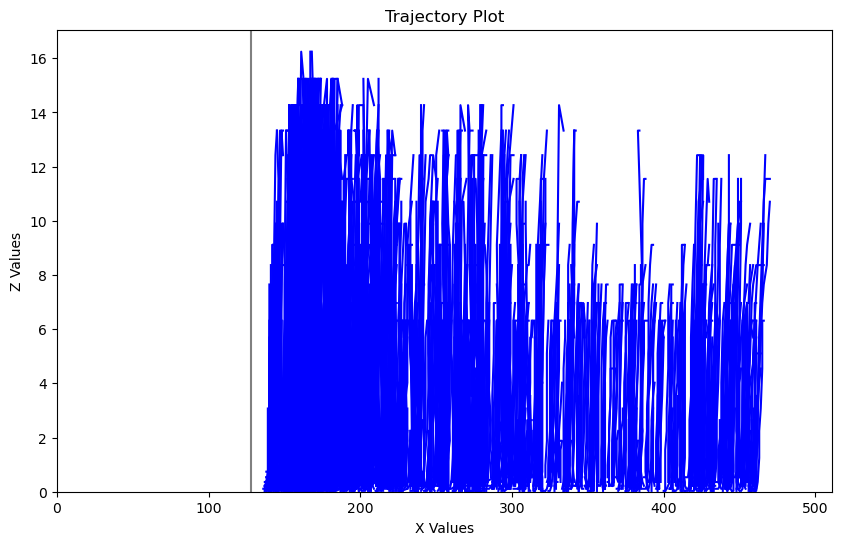

In [113]:
import matplotlib.pyplot as plt
import numpy as np

def CLTrajectoryPlot(ax, type):
    """
    Plot the trajectory based on the type with color corresponding to the type.
    
    Parameters:
    - ax: Matplotlib axes object to plot on.
    - type: Type of plot ('all', 'shallow', 'deep')
    """
    zhs = data['zh'].values
    xhs = data['xh'].values-data['xh'][0].values; # xhs = data['xh'].values
    
    # Select the correct arrays based on type
    if type == 'all':
        out_arr = ALL_out_arr.copy()
        after_array = ALL_out_after_array
    elif type == 'shallow':
        out_arr = SHALLOW_out_arr.copy()
        after_array = SHALLOW_out_after_array
    elif type == 'deep':
        out_arr = DEEP_out_arr.copy()
        after_array = DEEP_out_after_array
    
    # Loop through each row of out_arr to plot
    for row in range(out_arr.shape[0]):
        after = after_array[row]
        p = out_arr[row, 0]
        
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time']))  # Ensure not exceeding the buffer
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs = Z[ts, p]  # Assuming Z and X are defined and hold the data
        xs = X[ts, p]
        
        z_values = zhs[zs]
        x_values = xhs[xs]

        # Determine the color based on the 'type'
        if type == 'all':
            color = 'black'
        elif type == 'shallow':
            color = 'green'
        elif type == 'deep':
            color = 'blue'
        
        # Plot using ax.plot()
        ax.plot(x_values, z_values, color=color)


    #COLORING BY HEIGHT
    #     # Plot each segment with color based on z_value
    #     for i in range(len(z_values) - 1):
    #         ax.plot(x_values[i:i+2], z_values[i:i+2], color=cmap(norm(z_values[i])))
    
    # # Create a ScalarMappable object for the colorbar
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Create a figure and axes outside the function
fig, ax = plt.subplots(figsize=(10, 6))  # You can adjust the size as needed

# Call the function with the 'deep' type and pass in the axes object (ax)
CLTrajectoryPlot(ax=ax, type='deep')

# Optionally, add labels and title
ax.set_xlabel('X Values')
ax.set_ylabel('Z Values')
ax.set_title('Trajectory Plot')
xhs = data['xh'].values-data['xh'][0].values; ax.set_xlim((xhs[0],xhs[-1]))
ax.set_ylim(bottom=0)#,top=10)
ocean_fraction=2/8; coast=xhs[-1]*ocean_fraction; ax.axvline(coast,color='grey')

In [114]:
#AVERAGE TRAJECTORY

Text(0.5, 1.0, 'Average Tracked CL vs nonCL Parcel Trajectories')

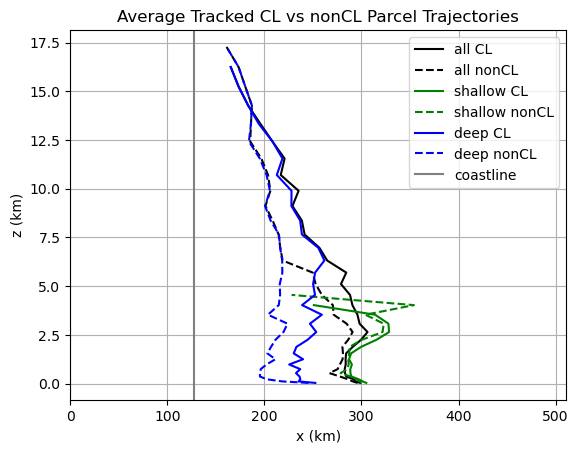

In [131]:
def CL_dzdx_profile(type,type2):
    zhs = data['zh'].values
    xhs = data['xh'].values-data['xh'][0].values; # xhs = data['xh'].values
    
    if type2=='CL':
        if type == 'all':
            out_arr = ALL_out_arr.copy()
            after_array = ALL_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_out_arr.copy()
            after_array = SHALLOW_out_after_array
        elif type == 'deep':
            out_arr = DEEP_out_arr.copy()
            after_array = DEEP_out_after_array
    elif type2=='nonCL':
        if type == 'all':
            out_arr = ALL_save_arr.copy()
            after_array = ALL_save_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_save_arr.copy()
            after_array = SHALLOW_save_after_array
        elif type == 'deep':
            out_arr = DEEP_save_arr.copy()
            after_array = DEEP_save_after_array
        

    
    zhs=data['zh'].values
    x_profile =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    x_profile[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        # ys=Y[ts,p]
        xs=X[ts,p]

        z_values = zhs[zs]
        x_values = xhs[xs]
        
        # vars=var_data[ts,p]
        np.add.at(x_profile[:, 0], zs, x_values)
        np.add.at(x_profile[:, 1], zs, 1)

    
    return x_profile

#PLOTTING
for type in ['all','shallow','deep']:
    CL_x_profile = CL_dzdx_profile(type=type,type2='CL')
    CL_x_profile_avg = averaged_profiles(CL_x_profile)
    
    nonCL_x_profile = CL_dzdx_profile(type=type,type2='nonCL')
    nonCL_x_profile_avg = averaged_profiles(nonCL_x_profile)

    if type == 'all':
        color = 'black'
    elif type == 'shallow':
        color = 'green'
    elif type == 'deep':
        color = 'blue'
    plt.plot(CL_x_profile_avg[:,0],CL_x_profile_avg[:,1],color=color,label=type+" CL")
    plt.plot(nonCL_x_profile_avg[:,0],nonCL_x_profile_avg[:,1],linestyle='dashed',color=color,label=type+" nonCL")
    plt.xlim((0,xhs[-1]))



################################################################
xhs = data['xh'].values-data['xh'][0].values; plt.xlim((xhs[0],xhs[-1]))
ocean_fraction=2/8; coast=xhs[-1]*ocean_fraction; plt.axvline(coast,color='grey',label='coastline')

plt.legend(loc='upper right')
plt.ylabel('z (km)');plt.xlabel('x (km)')
plt.grid()
plt.title("Average Tracked CL vs nonCL Parcel Trajectories")

In [116]:
#SAME BUT FOR SBZ

In [10]:
#FINDING SBZ CONVERGENCE
parcel_z=parcel['z'].data

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# TF=False
# if TF==False:
#     print('Loading In Data')
#     u_data=data['u'].interp(xf=data['xh']).data
#     v_data=data['v'].interp(yf=data['yh']).data
#     TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    # print('calculating convergence and taking mean')
    # Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}' + '.h5'
    with h5py.File(file_path, 'r') as f:
        Conv = f['conv'][:]
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{Np_str}' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep


def subset_SBZ(out_arr):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_arr.shape[0]):
        
        row=out_arr[ind]
        p=row[0]
        t=row[1]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_arr=out_arr[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

    valid_range=np.arange(out_arr.shape[0])
    nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
    return SBZ_out_arr,nonSBZ_out_arr


# #LOADING CL MAXS FROM CL TRACKING ALGORITHM
# folder = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Project_Algorithms/Tracking_Algorithms/'
# whereSBZ=xr.open_dataset(folder+f'whereCL_{res}_ONLY_SBZS.nc').load()
# whereSBZ=whereSBZ.isel(time=slice(0,len(data['time'])))
# whereSBZ=whereSBZ['maxconv_x']
# def Get_SBZ_X(t,z,y):
#     Conv_X_Max=whereSBZ[t,z,y,:].values
#     return Conv_X_Max
# def subset_SBZ(out_arr):

#     SBZ_subset=[]
#     # test=[] #TESTING
    
#     for ind in np.arange(out_arr.shape[0]):
        
#         row=out_arr[ind]
#         p=row[0]
#         t=row[1]

#         kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
#         value=X[t,p]
#         if np.any((value >= xmaxs - 2*kms) & (value <= xmaxs + 2*kms))==True:
#             SBZ_subset.append(ind)
#             # test.append(p) #TESTING
    
#     SBZ_out_arr=out_arr[SBZ_subset]
#     print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

#     valid_range=np.arange(out_arr.shape[0])
#     nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
#     print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
#     return SBZ_out_arr,nonSBZ_out_arr

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    elif type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    elif type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()

    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 
        
        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################
[ALL_SBZ_out_arr,ALL_nonSBZ_out_arr]=subset_SBZ(ALL_out_arr)
SHALLOW_SBZ_out_arr=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_arr)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_arr=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_arr)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_arr=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_arr)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_arr=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_arr)} DEEP nonSBZ CL parcels')

there are a total of 827 ALL SBZ CL parcels
there are a total of 14067 ALL nonSBZ CL parcels
there are a total of 432 SHALLOW SBZ CL parcels
there are a total of 10059 SHALLOW nonSBZ CL parcels
there are a total of 189 DEEP SBZ CL parcels
there are a total of 1324 DEEP nonSBZ CL parcels


In [11]:
#SBZ After Arrays
ALL_SBZ_out_after_array=find_after_time(ALL_SBZ_out_arr)
SHALLOW_SBZ_out_after_array=np.zeros(len(SHALLOW_SBZ_out_arr),dtype=int)
DEEP_SBZ_out_after_array=find_after_time(DEEP_SBZ_out_arr)

ALL_nonSBZ_out_after_array=find_after_time(ALL_nonSBZ_out_arr)
SHALLOW_nonSBZ_out_after_array=np.zeros(len(SHALLOW_nonSBZ_out_arr),dtype=int)
DEEP_nonSBZ_out_after_array=find_after_time(DEEP_nonSBZ_out_arr)

In [17]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

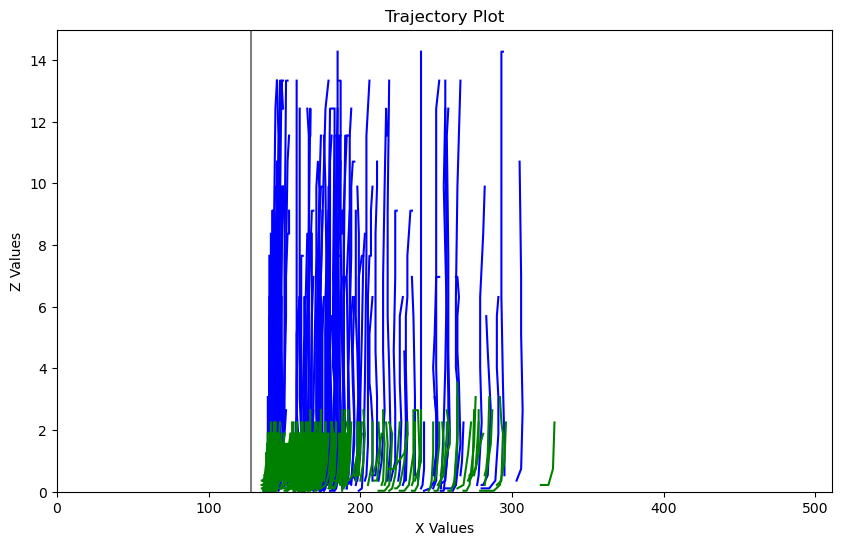

In [119]:
import matplotlib.pyplot as plt
import numpy as np

def SBZTrajectoryPlot(ax, type):
    """
    Plot the trajectory based on the type with color corresponding to the type.
    
    Parameters:
    - ax: Matplotlib axes object to plot on.
    - type: Type of plot ('all', 'shallow', 'deep')
    """
    zhs = data['zh'].values
    xhs = data['xh'].values-data['xh'][0].values; # xhs = data['xh'].values
    
    # Select the correct arrays based on type
    if type == 'all':
        out_arr = ALL_SBZ_out_arr.copy()
        after_array = ALL_SBZ_out_after_array
    elif type == 'shallow':
        out_arr = SHALLOW_SBZ_out_arr.copy()
        after_array = SHALLOW_SBZ_out_after_array
    elif type == 'deep':
        out_arr = DEEP_SBZ_out_arr.copy()
        after_array = DEEP_SBZ_out_after_array
    
    # Loop through each row of out_arr to plot
    for row in range(out_arr.shape[0]):
        after = after_array[row]
        p = out_arr[row, 0]
        
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time']))  # Ensure not exceeding the buffer
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs = Z[ts, p]  # Assuming Z and X are defined and hold the data
        xs = X[ts, p]
        
        z_values = zhs[zs]
        x_values = xhs[xs]

        # Determine the color based on the 'type'
        if type == 'all':
            color = 'black'
        elif type == 'shallow':
            color = 'green'
        elif type == 'deep':
            color = 'blue'
        
        # Plot using ax.plot()
        ax.plot(x_values, z_values, color=color)


    #COLORING BY HEIGHT
    #     # Plot each segment with color based on z_value
    #     for i in range(len(z_values) - 1):
    #         ax.plot(x_values[i:i+2], z_values[i:i+2], color=cmap(norm(z_values[i])))
    
    # # Create a ScalarMappable object for the colorbar
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Create a figure and axes outside the function
fig, ax = plt.subplots(figsize=(10, 6))  # You can adjust the size as needed

# Call the function with the 'deep' type and pass in the axes object (ax)
SBZTrajectoryPlot(ax=ax, type='deep')
SBZTrajectoryPlot(ax=ax, type='shallow')


# Optionally, add labels and title
ax.set_xlabel('X Values')
ax.set_ylabel('Z Values')
ax.set_title('Trajectory Plot')
xhs = data['xh'].values-data['xh'][0].values; ax.set_xlim((xhs[0],xhs[-1]))
ax.set_ylim(bottom=0)#,top=10)
ocean_fraction=2/8; coast=xhs[-1]*ocean_fraction; ax.axvline(coast,color='grey')

Text(0.5, 1.0, 'Average Tracked SBZ vs nonSBZ Parcel Trajectories')

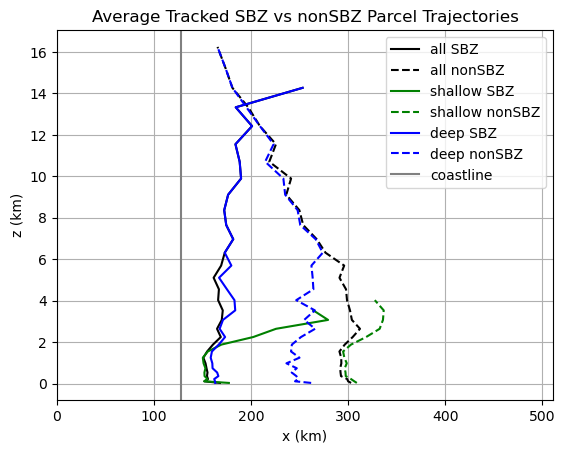

In [130]:
def SBZ_dzdx_profile(type,type2):
    zhs = data['zh'].values
    xhs = data['xh'].values-data['xh'][0].values; # xhs = data['xh'].values
    
    if type2=='SBZ':
        if type == 'all':
            out_arr = ALL_SBZ_out_arr.copy()
            after_array = ALL_SBZ_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_SBZ_out_arr.copy()
            after_array = SHALLOW_SBZ_out_after_array
        elif type == 'deep':
            out_arr = DEEP_SBZ_out_arr.copy()
            after_array = DEEP_SBZ_out_after_array
    elif type2=='nonSBZ':
        if type == 'all':
            out_arr = ALL_nonSBZ_out_arr.copy()
            after_array = ALL_nonSBZ_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_nonSBZ_out_arr.copy()
            after_array = SHALLOW_nonSBZ_out_after_array
        elif type == 'deep':
            out_arr = DEEP_nonSBZ_out_arr.copy()
            after_array = DEEP_nonSBZ_out_after_array
        

    
    zhs=data['zh'].values
    x_profile =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    x_profile[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        # ys=Y[ts,p]
        xs=X[ts,p]

        z_values = zhs[zs]
        x_values = xhs[xs]
        
        # vars=var_data[ts,p]
        np.add.at(x_profile[:, 0], zs, x_values)
        np.add.at(x_profile[:, 1], zs, 1)

    
    return x_profile

#PLOTTING
for type in ['all','shallow','deep']:
    SBZ_x_profile = SBZ_dzdx_profile(type=type,type2='SBZ')
    SBZ_x_profile_avg = averaged_profiles(SBZ_x_profile)
    
    nonSBZ_x_profile = SBZ_dzdx_profile(type=type,type2='nonSBZ')
    nonSBZ_x_profile_avg = averaged_profiles(nonSBZ_x_profile)

    if type == 'all':
        color = 'black'
    elif type == 'shallow':
        color = 'green'
    elif type == 'deep':
        color = 'blue'
    plt.plot(SBZ_x_profile_avg[:,0],SBZ_x_profile_avg[:,1],color=color,label=type+" SBZ")
    plt.plot(nonSBZ_x_profile_avg[:,0],nonSBZ_x_profile_avg[:,1],linestyle='dashed',color=color,label=type+" nonSBZ")
    plt.xlim((0,xhs[-1]))



################################################################
xhs = data['xh'].values-data['xh'][0].values; plt.xlim((xhs[0],xhs[-1]))
ocean_fraction=2/8; coast=xhs[-1]*ocean_fraction; plt.axvline(coast,color='grey',label='coastline')

plt.legend(loc='upper right')
plt.ylabel('z (km)');plt.xlabel('x (km)')
plt.grid()
plt.title("Average Tracked SBZ vs nonSBZ Parcel Trajectories")

In [ ]:
#ColdPool
########################################################################################

In [13]:
#COLD POOL
def get_ColdPool(out_arr1,out_arr2):
    arr1 = out_arr1[:,0] #CL
    arr2 = out_arr2[:,0] #nonSBZ
    common_values = np.intersect1d(arr1, arr2)
    indices_arr1 = np.where(np.isin(arr1, common_values))[0]  # Indices in arr1
    ColdPool_out_arr=out_arr1[indices_arr1]
    return ColdPool_out_arr

#ALL
ALL_ColdPool_out_arr = get_ColdPool(ALL_out_arr, ALL_nonSBZ_out_arr)
ALL_ColdPool_after_array=find_after_time(ALL_ColdPool_out_arr)

#SHALLOW
SHALLOW_ColdPool_out_arr = get_ColdPool(SHALLOW_out_arr, SHALLOW_nonSBZ_out_arr)
SHALLOW_ColdPool_after_array=np.zeros(len(ALL_ColdPool_after_array),dtype=int)

#DEEP
DEEP_ColdPool_out_arr = get_ColdPool(DEEP_out_arr, DEEP_nonSBZ_out_arr)
DEEP_ColdPool_after_array=find_after_time(DEEP_ColdPool_out_arr)

In [18]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

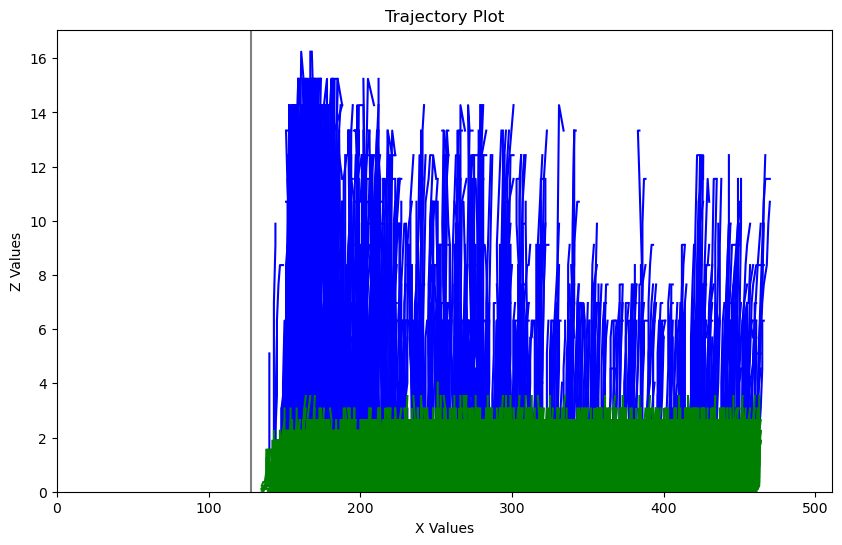

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def ColdPoolTrajectoryPlot(ax, type):
    """
    Plot the trajectory based on the type with color corresponding to the type.
    
    Parameters:
    - ax: Matplotlib axes object to plot on.
    - type: Type of plot ('all', 'shallow', 'deep')
    """
    zhs = data['zh'].values
    xhs = data['xh'].values-data['xh'][0].values; # xhs = data['xh'].values
    
    # Select the correct arrays based on type
    if type == 'all':
        out_arr = ALL_ColdPool_out_arr.copy()
        after_array = ALL_ColdPool_after_array
    elif type == 'shallow':
        out_arr = SHALLOW_ColdPool_out_arr.copy()
        after_array = SHALLOW_ColdPool_after_array
    elif type == 'deep':
        out_arr = DEEP_ColdPool_out_arr.copy()
        after_array = DEEP_ColdPool_after_array
    
    # Loop through each row of out_arr to plot
    for row in range(out_arr.shape[0]):
        after = after_array[row]
        p = out_arr[row, 0]
        
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time']))  # Ensure not exceeding the buffer
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs = Z[ts, p]  # Assuming Z and X are defined and hold the data
        xs = X[ts, p]
        
        z_values = zhs[zs]
        x_values = xhs[xs]

        # Determine the color based on the 'type'
        if type == 'all':
            color = 'black'
        elif type == 'shallow':
            color = 'green'
        elif type == 'deep':
            color = 'blue'
        
        # Plot using ax.plot()
        ax.plot(x_values, z_values, color=color)


    #COLORING BY HEIGHT
    #     # Plot each segment with color based on z_value
    #     for i in range(len(z_values) - 1):
    #         ax.plot(x_values[i:i+2], z_values[i:i+2], color=cmap(norm(z_values[i])))
    
    # # Create a ScalarMappable object for the colorbar
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Create a figure and axes outside the function
fig, ax = plt.subplots(figsize=(10, 6))  # You can adjust the size as needed

# Call the function with the 'deep' type and pass in the axes object (ax)
ColdPoolTrajectoryPlot(ax=ax, type='deep')
ColdPoolTrajectoryPlot(ax=ax, type='shallow')


# Optionally, add labels and title
ax.set_xlabel('X Values')
ax.set_ylabel('Z Values')
ax.set_title('Trajectory Plot')
xhs = data['xh'].values-data['xh'][0].values; ax.set_xlim((xhs[0],xhs[-1]))
ax.set_ylim(bottom=0)#,top=10)
ocean_fraction=2/8; coast=xhs[-1]*ocean_fraction; ax.axvline(coast,color='grey')

Text(0.5, 1.0, 'Average Tracked SBZ vs ColdPool Parcel Trajectories')

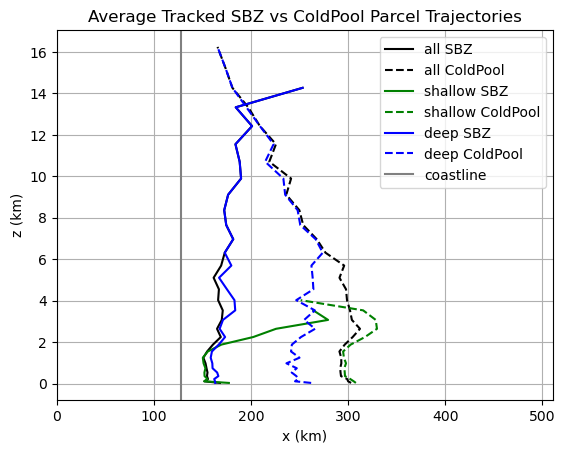

In [20]:
def ColdPool_dzdx_profile(type,type2):
    zhs = data['zh'].values
    xhs = data['xh'].values-data['xh'][0].values; # xhs = data['xh'].values
    
    if type2=='SBZ':
        if type == 'all':
            out_arr = ALL_SBZ_out_arr.copy()
            after_array = ALL_SBZ_out_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_SBZ_out_arr.copy()
            after_array = SHALLOW_SBZ_out_after_array
        elif type == 'deep':
            out_arr = DEEP_SBZ_out_arr.copy()
            after_array = DEEP_SBZ_out_after_array
    elif type2=='ColdPool':
        if type == 'all':
            out_arr = ALL_ColdPool_out_arr.copy()
            after_array = ALL_ColdPool_after_array
        elif type == 'shallow':
            out_arr = SHALLOW_ColdPool_out_arr.copy()
            after_array = SHALLOW_ColdPool_after_array
        elif type == 'deep':
            out_arr = DEEP_ColdPool_out_arr.copy()
            after_array = DEEP_ColdPool_after_array
        

    
    zhs=data['zh'].values
    x_profile =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    x_profile[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        # ys=Y[ts,p]
        xs=X[ts,p]

        z_values = zhs[zs]
        x_values = xhs[xs]
        
        # vars=var_data[ts,p]
        np.add.at(x_profile[:, 0], zs, x_values)
        np.add.at(x_profile[:, 1], zs, 1)

    
    return x_profile

#PLOTTING
for type in ['all','shallow','deep']:
    SBZ_x_profile = ColdPool_dzdx_profile(type=type,type2='SBZ')
    SBZ_x_profile_avg = averaged_profiles(SBZ_x_profile)
    
    ColdPool_x_profile = ColdPool_dzdx_profile(type=type,type2='ColdPool')
    ColdPool_x_profile_avg = averaged_profiles(ColdPool_x_profile)

    if type == 'all':
        color = 'black'
    elif type == 'shallow':
        color = 'green'
    elif type == 'deep':
        color = 'blue'
    plt.plot(SBZ_x_profile_avg[:,0],SBZ_x_profile_avg[:,1],color=color,label=type+" SBZ")
    plt.plot(ColdPool_x_profile_avg[:,0],ColdPool_x_profile_avg[:,1],linestyle='dashed',color=color,label=type+" ColdPool")
    plt.xlim((0,xhs[-1]))



################################################################
xhs = data['xh'].values-data['xh'][0].values; plt.xlim((xhs[0],xhs[-1]))
ocean_fraction=2/8; coast=xhs[-1]*ocean_fraction; plt.axvline(coast,color='grey',label='coastline')

plt.legend(loc='upper right')
plt.ylabel('z (km)');plt.xlabel('x (km)')
plt.grid()
plt.title("Average Tracked SBZ vs ColdPool Parcel Trajectories")